In [1]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx

# 设置H2分子的几何构型
bond_length = 1.7  # H2平衡键长（埃）
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length*1, 0., 0.)),
    ('H', (bond_length*2., 0., 0.)),
    ('H', (bond_length*3, 0., 0.)),
]

# 创建分子对象，使用STO-3G基组
mol = gto.M(atom=geometry, basis='STO-3G')

# 进行Hartree-Fock计算
mf = scf.RHF(mol).run(verbose=0)
E_hf = mf.e_tot
print(f"Hartree-Fock能量: {E_hf:.8f} Ha")

# 进行FCI计算作为参考
cisolver = fci.FCI(mf)
E_fci, fcivec = cisolver.kernel()
print(f"FCI能量: {E_fci:.8f} Ha")

# 使用NetKet创建哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Hartree-Fock能量: -1.71791801 Ha
FCI能量: -1.94369204 Ha


In [2]:
import itertools

# 排列组合
letters_alpha= [0,1,2,3]
letters_beta=  [4,5,6,7]
combinations_alpha = itertools.combinations(letters_alpha, 2)
combinations_beta =  itertools.combinations(letters_beta, 2)
clusters = list(combinations_alpha) + list(combinations_beta)
print(clusters)

[(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3), (4, 5), (4, 6), (4, 7), (5, 6), (5, 7), (6, 7)]


In [3]:
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=4,  # 总空间轨道数
    s = 1/2,
    n_fermions_per_spin=(2, 2)  # 每种自旋的电子数
)

# g = nk.graph.Graph(edges=[(0,2),(1,3),(2,0),(3,1)])
g = nk.graph.Graph(edges=clusters)
# g = nk.graph.Graph(edges=cluster)
sa = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

In [4]:
import jax
import jax.numpy as jnp
from flax import nnx

class FFN_Amplitude(nnx.Module):

    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):
        self.alpha = alpha
        self.linear = nnx.Linear(in_features=N, out_features=alpha * N, rngs=rngs)

    def __call__(self, x: jax.Array):
        y = self.linear(x)
        y = nnx.relu(y)
        return jnp.sum(y, axis=-1)
    

class FFN_Phase(nnx.Module):

    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):
        self.alpha = alpha
        self.linear = nnx.Linear(in_features=N, out_features=alpha * N, rngs=rngs)

    def __call__(self, x: jax.Array):
        y = self.linear(x)
        y = nnx.relu(y)
        return jnp.sum(y, axis=-1)
    
class FFN(nnx.Module):
    def __init__(self,N:int,alpha:int,rngs_amplitude: nnx.Rngs,rngs_phase:nnx.Rngs) -> None:
        self.ffn_amplitude = FFN_Amplitude(N=N,alpha=alpha,rngs=rngs_amplitude)
        self.ffn_phase = FFN_Phase(N=N,alpha=alpha,rngs=rngs_phase)
        
    def __call__(self, x:jax.Array):
        y = self.ffn_amplitude(x) + 1j*self.ffn_phase(x)
        return y        

In [5]:
N = 8
ffnn_model = FFN(N=N, alpha=2, rngs_amplitude=nnx.Rngs(2),rngs_phase=nnx.Rngs(3))
vs = nk.vqs.MCState(sa, ffnn_model, n_discard_per_chain=10, n_samples=512)

# 设置优化器
opt = nk.optimizer.Sgd(learning_rate=0.05)
sr = nk.optimizer.SR(diag_shift=0.01)

# 创建VMC驱动器
gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)

# 运行优化
exp_name = "h4_molecule_ffnn_layer1"

In [6]:
import jax.tree_util as jtu

# 统计参数量
param_leaves = jtu.tree_leaves(nnx.state(ffnn_model, nnx.Param))
total_params = sum(leaf.size for leaf in param_leaves)

print(f"模型参数量: {total_params:,}")


模型参数量: 288


In [7]:
gs.run(300, out=exp_name)

100%|██████████| 300/300 [00:11<00:00, 26.95it/s, Energy=-1.9084+0.0031j ± 0.0036 [σ²=0.0066, R̂=1.0126]]


(JsonLog('h4_molecule_ffnn_layer1', mode=write, autoflush_cost=0.005)
   Runtime cost:
   	Log:    0.0501253604888916
   	Params: 0.04846310615539551,)

In [14]:
gs.energy.mean.real

Array(-1.90844105, dtype=float64)

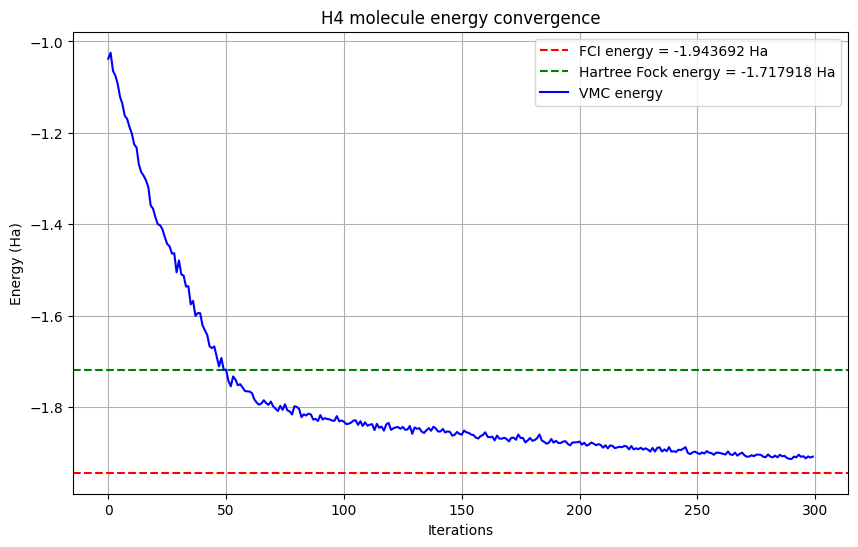

最终VMC能量: -1.90844105 Ha
最终FCI能量: -1.94369204 Ha
最终Hartree-Fock能量: -1.71791801 Ha
与FCI能量误差: 0.03525098 Ha


In [8]:
############## 绘图 #################
# 获取精确对角化能量（FCI能量）
exp_name = "h4_molecule_ffnn_layer1"
ed_energies = np.array([E_fci])  # H2只有一个基态能量

# 读取日志数据
with open(f"{exp_name}.log") as f:
    data = json.load(f)

x = data["Energy"]["iters"]
y = data["Energy"]["Mean"]['real']

# 绘制能量收敛曲线
plt.figure(figsize=(10, 6))
plt.axhline(ed_energies[0], color="red", linestyle="--", label=f"FCI energy = {E_fci:.6f} Ha")
plt.axhline(E_hf, color="green", linestyle="--", label=f"Hartree Fock energy = {E_hf:.6f} Ha")
plt.plot(x, y, 'b-', label="VMC energy")
plt.xlabel("Iterations")
plt.ylabel("Energy (Ha)")
plt.title("H4 molecule energy convergence")
plt.legend()
plt.grid(True)
plt.show()

# 打印最终结果
print(f"最终VMC能量: {y[-1]:.8f} Ha")
print(f"最终FCI能量: {E_fci:.8f} Ha")
print(f"最终Hartree-Fock能量: {E_hf:.8f} Ha")
print(f"与FCI能量误差: {abs(y[-1] - E_fci):.8f} Ha")


In [9]:
gs.energy.mean

Array(-1.90844105+0.00314389j, dtype=complex128)

In [10]:
# 假设 vs 是你已经训练好的 MCState
import numpy as np
import matplotlib.pyplot as plt

# 1. 生成大量样本以获得准确的概率分布
n_samples = 10000  # 增加样本数量以获得更准确的概率
samples = vs.sample(n_samples=n_samples)

# 2. 将样本重塑为二维数组 (n_samples, n_orbitals)
samples_flat = samples.reshape(-1, samples.shape[-1])

# 3. 统计每个组态的出现次数
unique_configs, counts = np.unique(samples_flat, axis=0, return_counts=True)

# 4. 计算概率
probabilities = counts / np.sum(counts)

# 5. 按概率排序
sorted_indices = np.argsort(probabilities)[::-1]
sorted_configs = unique_configs[sorted_indices]
sorted_probs = probabilities[sorted_indices]

print("组态及其概率分布:")
print("组态(轨道占据)    概率      物理解释")
print("-" * 50)
for i, (config, prob) in enumerate(zip(sorted_configs[:10], sorted_probs[:10])):  # 显示前10个主要组态
    # 解释组态的物理意义
    occupied_orbitals = np.where(config == 1)[0]
    print(f"{config}         {prob:.6f}   电子占据轨道: {occupied_orbitals}")


组态及其概率分布:
组态(轨道占据)    概率      物理解释
--------------------------------------------------
[1 1 0 0 1 1 0 0]         0.269800   电子占据轨道: [0 1 4 5]
[1 0 1 0 1 1 0 0]         0.131300   电子占据轨道: [0 2 4 5]
[1 1 0 0 1 0 1 0]         0.130600   电子占据轨道: [0 1 4 6]
[1 0 1 0 1 0 1 0]         0.128800   电子占据轨道: [0 2 4 6]
[0 1 0 1 0 1 0 1]         0.030500   电子占据轨道: [1 3 5 7]
[0 1 1 0 1 0 0 1]         0.026800   电子占据轨道: [1 2 4 7]
[1 0 0 1 0 1 1 0]         0.025500   电子占据轨道: [0 3 5 6]
[1 0 1 0 0 1 1 0]         0.024000   电子占据轨道: [0 2 5 6]
[1 0 1 0 1 0 0 1]         0.021000   电子占据轨道: [0 2 4 7]
[0 1 1 0 1 0 1 0]         0.020400   电子占据轨道: [1 2 4 6]
